# **Exercise 2**
Solve another regression problem chosen from the following list:
- [Seoul Bike Sharing Demand Data Set](https://archive.ics.uci.edu/ml/datasets/Seoul+Bike+Sharing+Demand);
- [
Bike Sharing Dataset Data Set](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset);
- [PM2.5 Data of Five Chinese Cities Data Set](https://archive.ics.uci.edu/dataset/394/pm2+5+data+of+five+chinese+cities);
- [
Metro Interstate Traffic Volume Data Set](https://archive.ics.uci.edu/ml/datasets/Metro+Interstate+Traffic+Volume);
- [Wine Quality Data Set](https://archive.ics.uci.edu/ml/datasets/Wine+Quality).

In [1]:
!wget https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip

!unzip -q seoul+bike+sharing+demand.zip

!rm seoul+bike+sharing+demand.zip

--2026-04-20 14:15:36--  https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘seoul+bike+sharing+demand.zip.1’

seoul+bike+sharing+     [  <=>               ] 590.13K  2.36MB/s    in 0.2s    

2026-04-20 14:15:36 (2.36 MB/s) - ‘seoul+bike+sharing+demand.zip.1’ saved [604298]

replace SeoulBikeData.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [2]:
# useful modules
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression

In [3]:
# utility functions
def plot_history(history,metric=None):
  fig, ax1 = plt.subplots(figsize=(10, 8))

  epoch_count=len(history.history['loss'])

  line1,=ax1.plot(range(1,epoch_count+1),history.history['loss'],label='train_loss',color='orange')
  ax1.plot(range(1,epoch_count+1),history.history['val_loss'],label='val_loss',color = line1.get_color(), linestyle = '--')
  ax1.set_xlim([1,epoch_count])
  ax1.set_ylim([0, max(max(history.history['loss']),max(history.history['val_loss']))])
  ax1.set_ylabel('loss',color = line1.get_color())
  ax1.tick_params(axis='y', labelcolor=line1.get_color())
  ax1.set_xlabel('Epochs')
  _=ax1.legend(loc='lower left')

  if (metric!=None):
    ax2 = ax1.twinx()
    line2,=ax2.plot(range(1,epoch_count+1),history.history[metric],label='train_'+metric)
    ax2.plot(range(1,epoch_count+1),history.history['val_'+metric],label='val_'+metric,color = line2.get_color(), linestyle = '--')
    ax2.set_ylim([0, max(max(history.history[metric]),max(history.history['val_'+metric]))])
    ax2.set_ylabel(metric,color=line2.get_color())
    ax2.tick_params(axis='y', labelcolor=line2.get_color())
    _=ax2.legend(loc='upper right')

def plot_prediction_results(y,y_pred,output_labels,bin_count=50):
  fig, axs = plt.subplots(2,len(output_labels),figsize=(25, 10),squeeze=False)

  for i in range(len(output_labels)):
    axs[0,i].set_title(output_labels[i])
    axs[0,i].scatter(y[:,i], y_pred[:,i],s=1)
    axs[0,i].set_xlabel('True Values')
    if i==0:
      axs[0,i].set_ylabel('Predictions')
    max_value=max(max(y[:,i]),max(y_pred[:,i]))
    x_lims = [0, max_value]
    y_lims = [min(0,min(y[:,i]),min(y_pred[:,i])), max_value]
    axs[0,i].set_xlim(x_lims)
    axs[0,i].set_ylim(y_lims)
    axs[0,i].plot(y_lims, y_lims, color='k')

    errors = y[:,i]-y_pred[:,i]
    axs[1,i].hist(errors, bins=bin_count)
    axs[1,i].set_xlabel('Prediction Error')
    if i==0:
      axs[1,i].set_ylabel('Count')
    axs[1,i].set_xlim([min(errors),max(errors)])

In [4]:
import os
import glob

# See what's in the current directory
print(os.listdir('.'))

# Try to see if the directory exists
print(os.path.exists('seoul+bike+sharing+demand'))

# See what glob actually finds
print(glob.glob('seoul+bike+sharing+demand' + "/*.csv"))

['.config', 'SeoulBikeData.csv', 'seoul+bike+sharing+demand.zip.1', 'sample_data']
False
[]


In [5]:

dataframe = pd.read_csv('SeoulBikeData.csv', encoding='latin-1')

In [6]:
# visualization
row_count=5

dataframe.sample(row_count)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
6635,03/09/2018,443,11,23.7,86,0.6,1798,21.2,0.31,0.0,0.0,Autumn,No Holiday,Yes
8402,16/11/2018,376,2,7.7,63,1.0,704,1.0,0.00,0.0,0.0,Autumn,No Holiday,Yes
8100,03/11/2018,0,12,16.5,37,1.8,1060,1.7,2.14,0.0,0.0,Autumn,No Holiday,No
7695,17/10/2018,1175,15,18.3,21,2.7,2000,-4.4,2.02,0.0,0.0,Autumn,No Holiday,Yes
2486,14/03/2018,878,14,21.1,42,4.3,2000,7.6,2.49,0.0,0.0,Spring,No Holiday,Yes


In [ ]:
# brief summary of the dataframe
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [7]:
# show overall statistics
dataframe.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Rented Bike Count,8760.0,704.602055,644.997468,0.0,191.00,504.50,1065.25,3556.00
Hour,8760.0,11.500000,6.922582,0.0,5.75,11.50,17.25,23.00
Temperature(°C),8760.0,12.882922,11.944825,-17.8,3.50,13.70,22.50,39.40
Humidity(%),8760.0,58.226256,20.362413,0.0,42.00,57.00,74.00,98.00
Wind speed (m/s),8760.0,1.724909,1.036300,0.0,0.90,1.50,2.30,7.40
Visibility (10m),8760.0,1436.825799,608.298712,27.0,940.00,1698.00,2000.00,2000.00
Dew point temperature(°C),8760.0,4.073813,13.060369,-30.6,-4.70,5.10,14.80,27.20
Solar Radiation (MJ/m2),8760.0,0.569111,0.868746,0.0,0.00,0.01,0.93,3.52
Rainfall(mm),8760.0,0.148687,1.128193,0.0,0.00,0.00,0.00,35.00
Snowfall (cm),8760.0,0.075068,0.436746,0.0,0.00,0.00,0.00,8.80


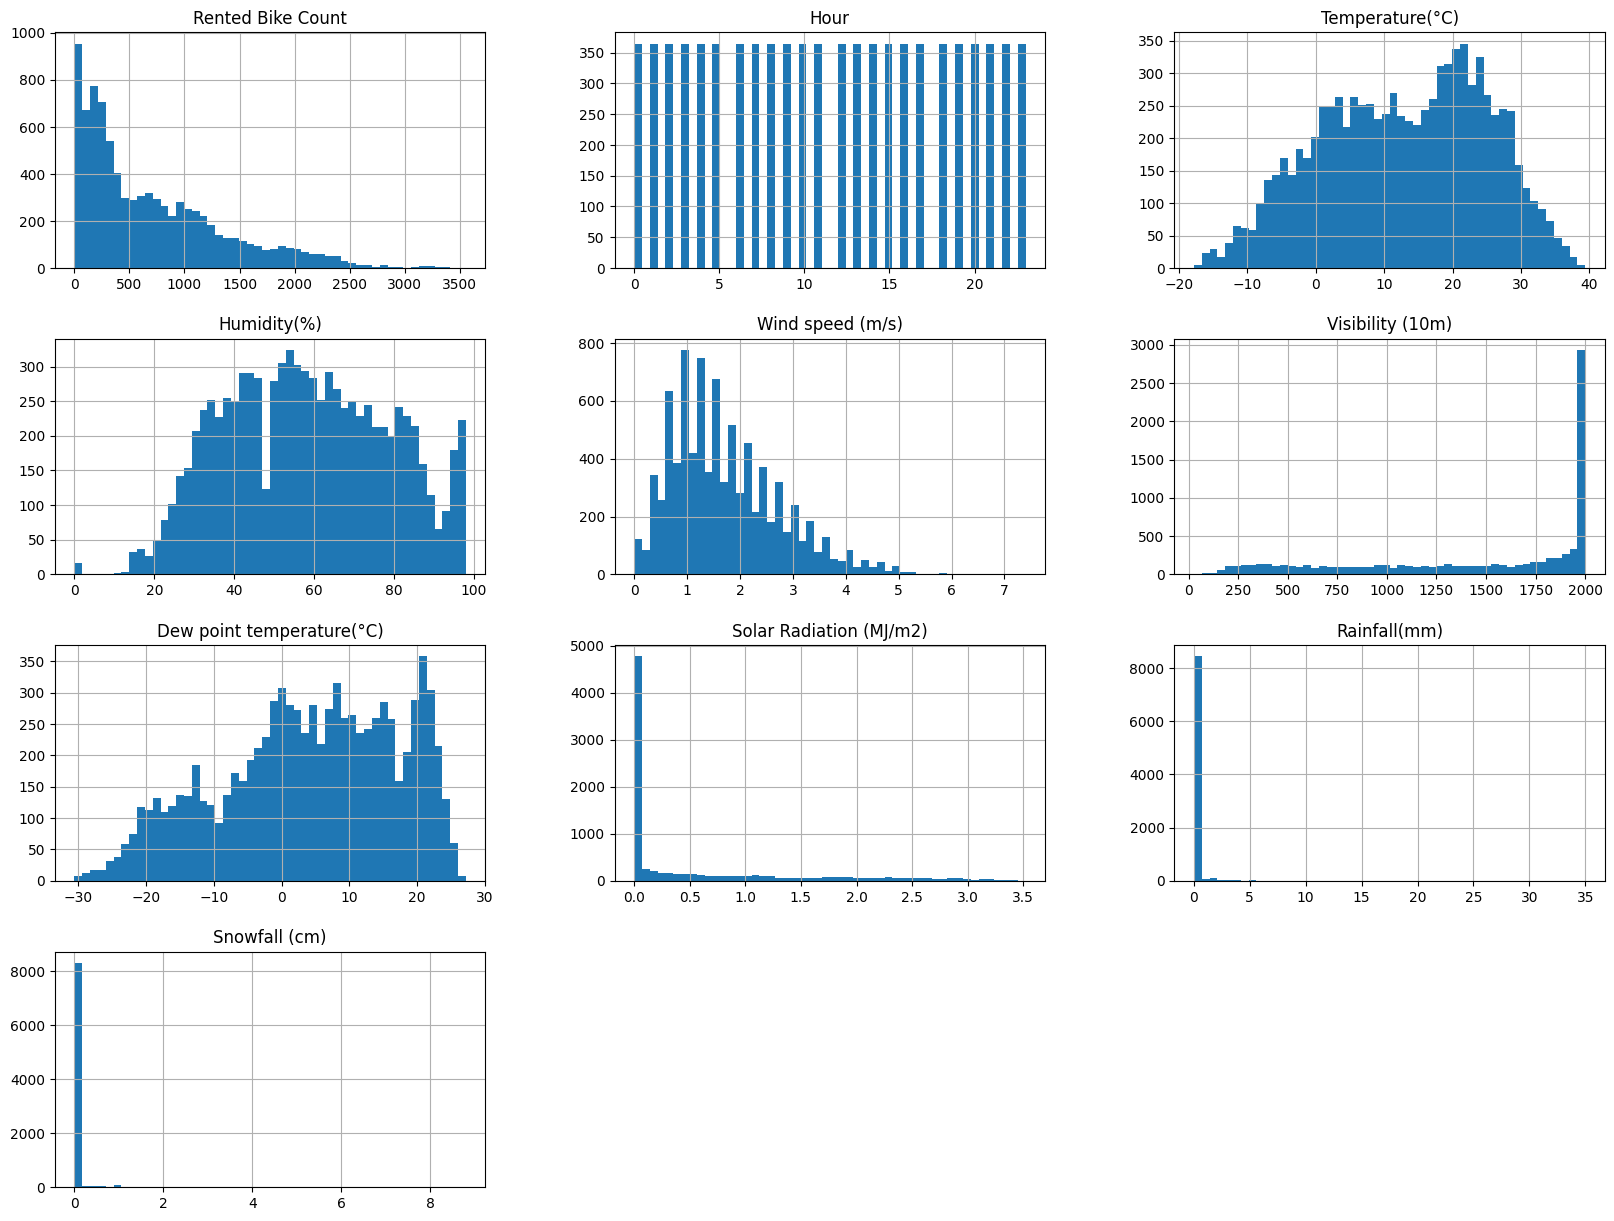

In [8]:
# data visualization fast
dataframe.hist(bins=50, figsize=(20,15))
plt.show()

## Data preparation

In [9]:
# watch for missing values
dataframe.isna().sum()
# there are no missing values, no need to remove rows

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


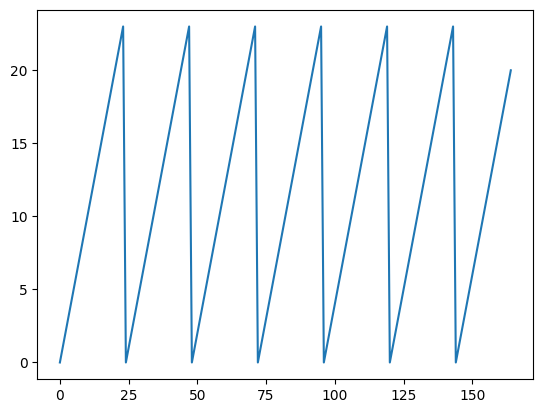

In [10]:
# encode cyclical data
plt.plot(dataframe['Hour'][:165].values)

plt.show()

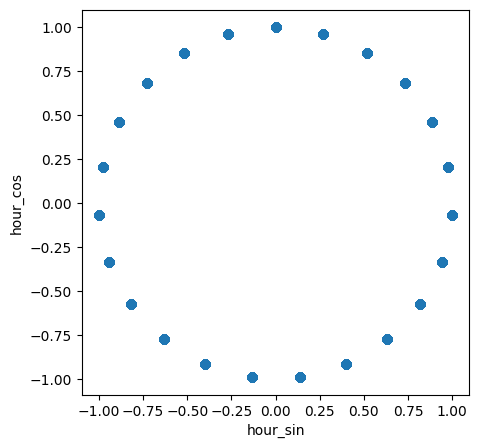

In [11]:
hour_sin = np.sin(2 * np.pi * dataframe['Hour']/23.0)
hour_cos = np.cos(2 * np.pi * dataframe['Hour']/23.0)

plt.figure(figsize=(5, 5))
plt.xlabel('hour_sin')
plt.ylabel('hour_cos')
plt.scatter(hour_sin,hour_cos)

plt.show()

In [12]:
dataframe['hour_sin']=hour_sin
dataframe['hour_cos']=hour_cos

dataframe.sample(row_count)

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,hour_sin,hour_cos
5189,05/07/2018,326,5,23.5,80,0.3,838,19.8,0.00,0.0,0.0,Summer,No Holiday,Yes,0.979084,0.203456
4112,21/05/2018,1785,8,15.3,30,1.3,2000,-2.2,1.30,0.0,0.0,Spring,No Holiday,Yes,0.816970,-0.576680
3571,28/04/2018,1590,19,16.9,33,1.3,1965,0.5,0.34,0.0,0.0,Spring,No Holiday,Yes,-0.887885,0.460065
2996,04/04/2018,1374,20,12.8,56,2.0,2000,4.2,0.00,0.0,0.0,Spring,No Holiday,Yes,-0.730836,0.682553
8665,27/11/2018,408,1,4.5,82,0.4,350,1.6,0.00,0.0,0.0,Autumn,No Holiday,Yes,0.269797,0.962917


In [13]:
print(len(dataframe))

8760


In [14]:
# now we drop not useful cols
dataframe = dataframe.drop(['Hour'], axis=1)
dataframe.sample(row_count)

,Date,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,hour_sin,hour_cos
7031,19/09/2018,0,20.4,57,0.9,2000,11.5,0.00,0.0,0.0,Autumn,No Holiday,No,-2.449294e-16,1.000000
1949,20/02/2018,79,-1.8,82,1.3,375,-4.4,0.00,0.0,0.0,Winter,No Holiday,Yes,9.790841e-01,0.203456
3347,19/04/2018,795,16.1,23,2.5,1361,-5.0,2.52,0.0,0.0,Spring,No Holiday,Yes,1.361666e-01,-0.990686
237,10/12/2017,167,0.0,59,3.0,1862,-7.0,0.00,0.0,0.0,Winter,No Holiday,Yes,-5.195840e-01,0.854419
3933,13/05/2018,1571,14.1,86,0.9,535,11.7,0.00,0.0,0.0,Spring,No Holiday,Yes,-5.195840e-01,0.854419


In [15]:
label_enc_dataframe = dataframe.copy()

label_enc_dataframe['Date'] = pd.to_datetime(dataframe['Date'], format='%d/%m/%Y')

# One-hot encode all categorical columns
label_enc_dataframe = pd.get_dummies(label_enc_dataframe, columns=['Seasons', 'Holiday', 'Functioning Day'], dtype=float)

# Drop the Date column since it's not useful for the model
label_enc_dataframe = label_enc_dataframe.drop(['Date'], axis=1)

label_enc_dataframe.dtypes

,0
Rented Bike Count,int64
Temperature(°C),float64
Humidity(%),int64
Wind speed (m/s),float64
Visibility (10m),int64
Dew point temperature(°C),float64
Solar Radiation (MJ/m2),float64
Rainfall(mm),float64
Snowfall (cm),float64
hour_sin,float64


In [16]:
# Split features and target values

target_data = ['Rented Bike Count']

dataframe_x = label_enc_dataframe.drop(target_data, axis=1)
dataframe_y = label_enc_dataframe[target_data]

In [17]:
dataframe_x.sample(row_count)

,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),hour_sin,hour_cos,Seasons_Autumn,Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_Holiday,Holiday_No Holiday,Functioning Day_No,Functioning Day_Yes
7755,9.5,77,0.4,1611,5.6,0.00,0.0,0.0,0.730836,0.682553,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8332,4.9,63,0.0,1397,-1.5,0.00,0.0,0.0,0.887885,0.460065,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
8259,10.3,81,0.7,361,7.1,0.00,0.0,0.0,0.730836,0.682553,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2866,16.0,29,1.4,1708,-2.0,1.79,0.0,0.0,0.398401,-0.917211,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4832,20.6,77,1.2,566,16.4,0.53,0.0,0.0,0.816970,-0.576680,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [18]:
dataframe_y.sample(row_count)

,Rented Bike Count
5087,919
8653,718
1409,178
7803,175
8285,111


In [19]:
# we are starting getting handy with the dataset :)
x = dataframe_x.to_numpy()
y = dataframe_y.to_numpy()

print('Feature shape: ', x.shape)
print('Target shape: ', y.shape)

Feature shape:  (8760, 18)
Target shape:  (8760, 1)


In [20]:
#Split data into training and test sets

test_size = 0.25

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=test_size, random_state = 1, shuffle = True)

print('Train feature shape: ', train_x.shape)
print('Train target shape: ', train_y.shape)
print('Test feature shape: ', test_x.shape)
print('Test target shape: ', test_y.shape)

Train feature shape:  (6570, 18)
Train target shape:  (6570, 1)
Test feature shape:  (2190, 18)
Test target shape:  (2190, 1)


## Linear Regression

In [21]:
linear_model = LinearRegression().fit(train_x, train_y)

In [22]:
# predict method return the predictions
train_y_pred = linear_model.predict(train_x)
test_y_pred = linear_model.predict(test_x)

print('Train predictions shape: ',train_y_pred.shape)
print('Test predictions shape: ',test_y_pred.shape)

Train predictions shape:  (6570, 1)
Test predictions shape:  (2190, 1)


In [23]:
# regression accuracy can be measured using the RMSE
rmse_train = root_mean_squared_error(train_y,train_y_pred)
rmse_test = root_mean_squared_error(test_y,test_y_pred)

print('RMSE - Train: {:.3f} Test: {:.3f}'.format(rmse_train,rmse_test))

RMSE - Train: 438.316 Test: 438.508


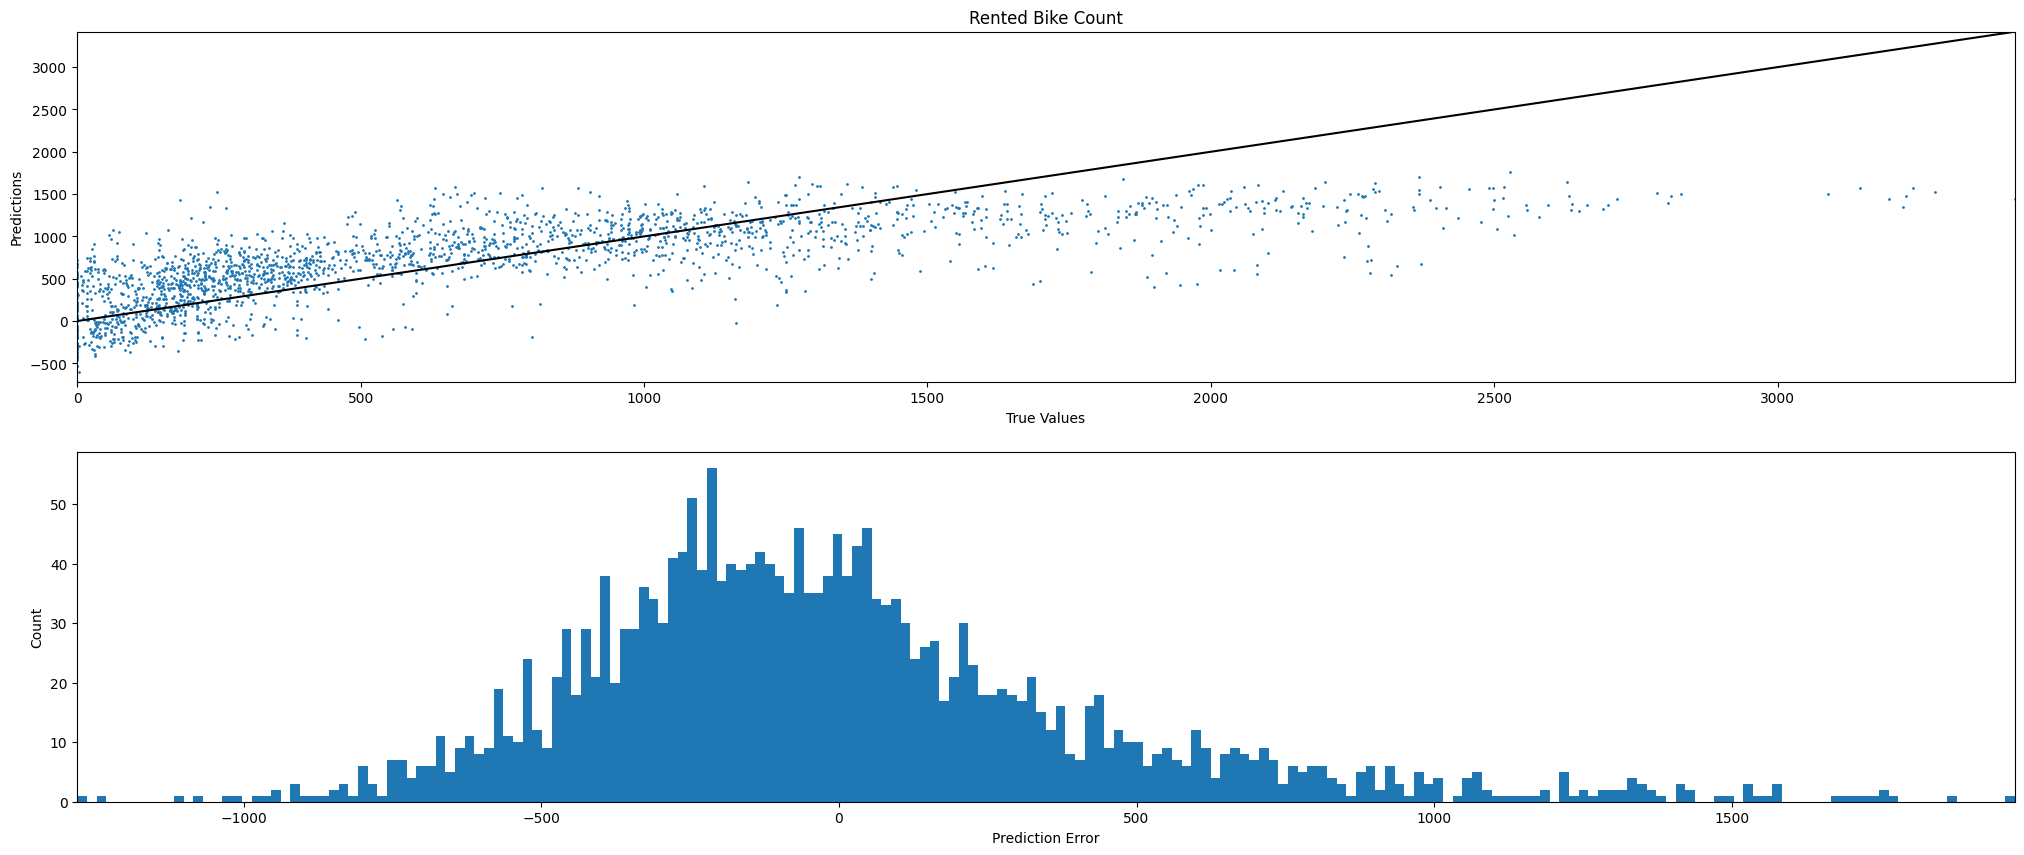

In [24]:
# visualize the error distribution
plot_prediction_results(test_y, test_y_pred, target_data, 200)

In [25]:
# best and worst predictions
rmse_test_instances=root_mean_squared_error(test_y.transpose(),test_y_pred.transpose(),multioutput='raw_values')

rmse_test_instances_sorted_indices=np.argsort(rmse_test_instances)

In [26]:
# worst predictions of the model
with np.printoptions(precision=1, suppress=True):
  print('Worst RMSE:')
  print(rmse_test_instances[rmse_test_instances_sorted_indices[-row_count:]])

  print('True values:')
  print(test_y[rmse_test_instances_sorted_indices[-row_count:]])

  print('Predicted values:')
  print(test_y_pred[rmse_test_instances_sorted_indices[-row_count:]])

Worst RMSE:
[1748.6 1749.9 1777.  1876.2 1975.1]
True values:
[[3196]
 [3277]
 [2317]
 [3221]
 [3418]]
Predicted values:
[[1447.4]
 [1527.1]
 [ 540. ]
 [1344.8]
 [1442.9]]


## Linear neural network


In [27]:
def build_linear_nn(input_count, output_count):
    model = keras.Sequential(
        [
            layers.Input(shape=(input_count,)),
            layers.Dense(output_count)
        ]
    )
    return model

In [28]:
# here we create the model
linear_nn = build_linear_nn(train_x.shape[1], train_y.shape[1])

In [29]:
# visualize the model first time!!
linear_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            19 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (76.00 B)

 Trainable params: 19 (76.00 B)

 Non-trainable params: 0 (0.00 B)

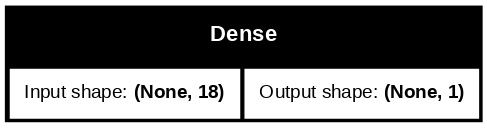

In [30]:
keras.utils.plot_model(linear_nn,show_shapes=True, show_layer_names=False,dpi=100)

In [31]:
linear_nn.compile(loss='mse', optimizer='SGD',metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])

In [32]:
val_size=0.25

train_x, val_x, train_y, val_y = train_test_split(train_x, train_y, test_size = val_size,random_state = 1,shuffle=True)

print('Train feature shape: ',train_x.shape)
print('Train target shape: ',train_y.shape)
print('Validation feature shape: ',val_x.shape)
print('Validation target shape: ',val_y.shape)

Train feature shape:  (4927, 18)
Train target shape:  (4927, 1)
Validation feature shape:  (1643, 18)
Validation target shape:  (1643, 1)


In [33]:
epoch_count = 2
batch_size = 512

history = linear_nn.fit(train_x, train_y,validation_data=(val_x,val_y), epochs=epoch_count, batch_size=batch_size,shuffle = True)

Epoch 1/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: nan - rmse: nan - val_loss: nan - val_rmse: nan
Epoch 2/2
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: nan - rmse: nan - val_loss: nan - val_rmse: nan


In [34]:
# good practice to do data normalization
scaler = StandardScaler().fit(train_x)
train_x = scaler.transform(train_x)
val_x=scaler.transform(val_x)
test_x = scaler.transform(test_x)

In [35]:
epoch_count = 10
batch_size = 512

linear_nn=build_linear_nn(train_x.shape[1],train_y.shape[1])

linear_nn.compile(loss='mse', optimizer='SGD',metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])

history = linear_nn.fit(train_x, train_y,validation_data=(val_x,val_y), epochs=epoch_count, batch_size=batch_size,shuffle = True)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 763981.1250 - rmse: 874.0601 - val_loss: 630845.1875 - val_rmse: 794.2576
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 542044.8750 - rmse: 736.2370 - val_loss: 471537.1250 - val_rmse: 686.6856
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 418081.0312 - rmse: 646.5919 - val_loss: 376781.5312 - val_rmse: 613.8253
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 342013.6250 - rmse: 584.8193 - val_loss: 316953.8125 - val_rmse: 562.9865
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 293376.4375 - rmse: 541.6423 - val_loss: 278248.8750 - val_rmse: 527.4930
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 261494.1875 - rmse: 511.3650 - val_loss: 252810.5312 - val_rmse: 502.8027
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 240328.8125 - rmse: 490.2334 - val_loss: 235698.6719 - val_rmse: 485.4881
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 226077.328

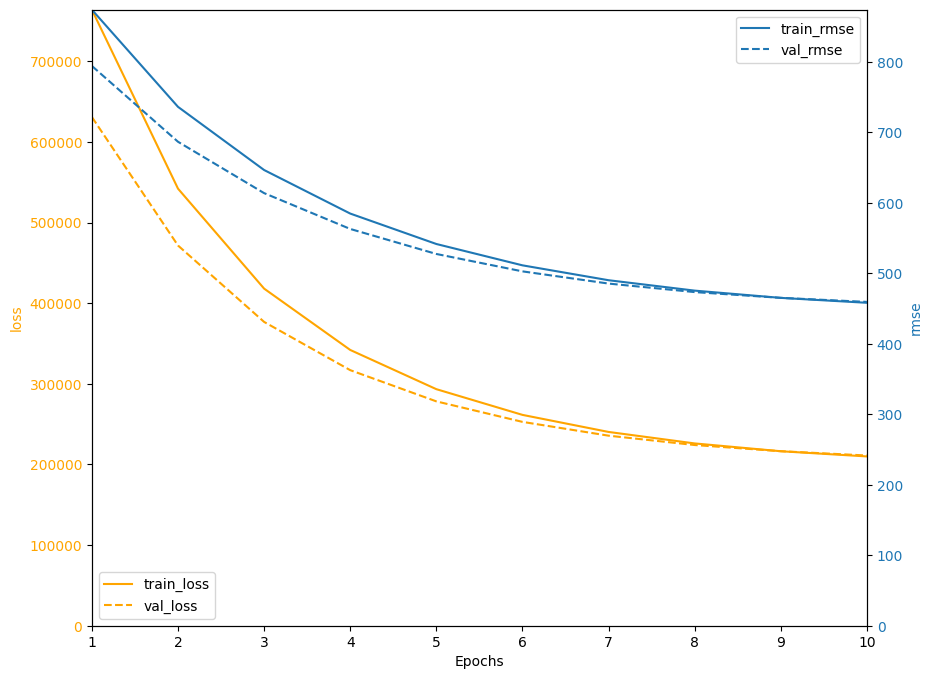

In [36]:
plot_history(history,'rmse')

### Performance evaluation

In [38]:
train_y_pred = linear_nn.predict(train_x)
val_y_pred = linear_nn.predict(val_x)
test_y_pred = linear_nn.predict(test_x)

print('Train predictions shape: ', train_y_pred.shape)
print('Validation predictions shape: ', val_y_pred.shape)
print('Test predictions shape: ', test_y_pred.shape)

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Train predictions shape:  (4927, 1)
Validation predictions shape:  (1643, 1)
Test predictions shape:  (2190, 1)


In [39]:
rmse_train = root_mean_squared_error(train_y,train_y_pred)
rmse_val = root_mean_squared_error(val_y,val_y_pred)
rmse_test = root_mean_squared_error(test_y,test_y_pred)

print('RMSE - Train: {:.3f} Val: {:.3f} Test: {:.3f}'.format(rmse_train,rmse_val,rmse_test))

RMSE - Train: 455.062 Val: 459.468 Test: 452.255


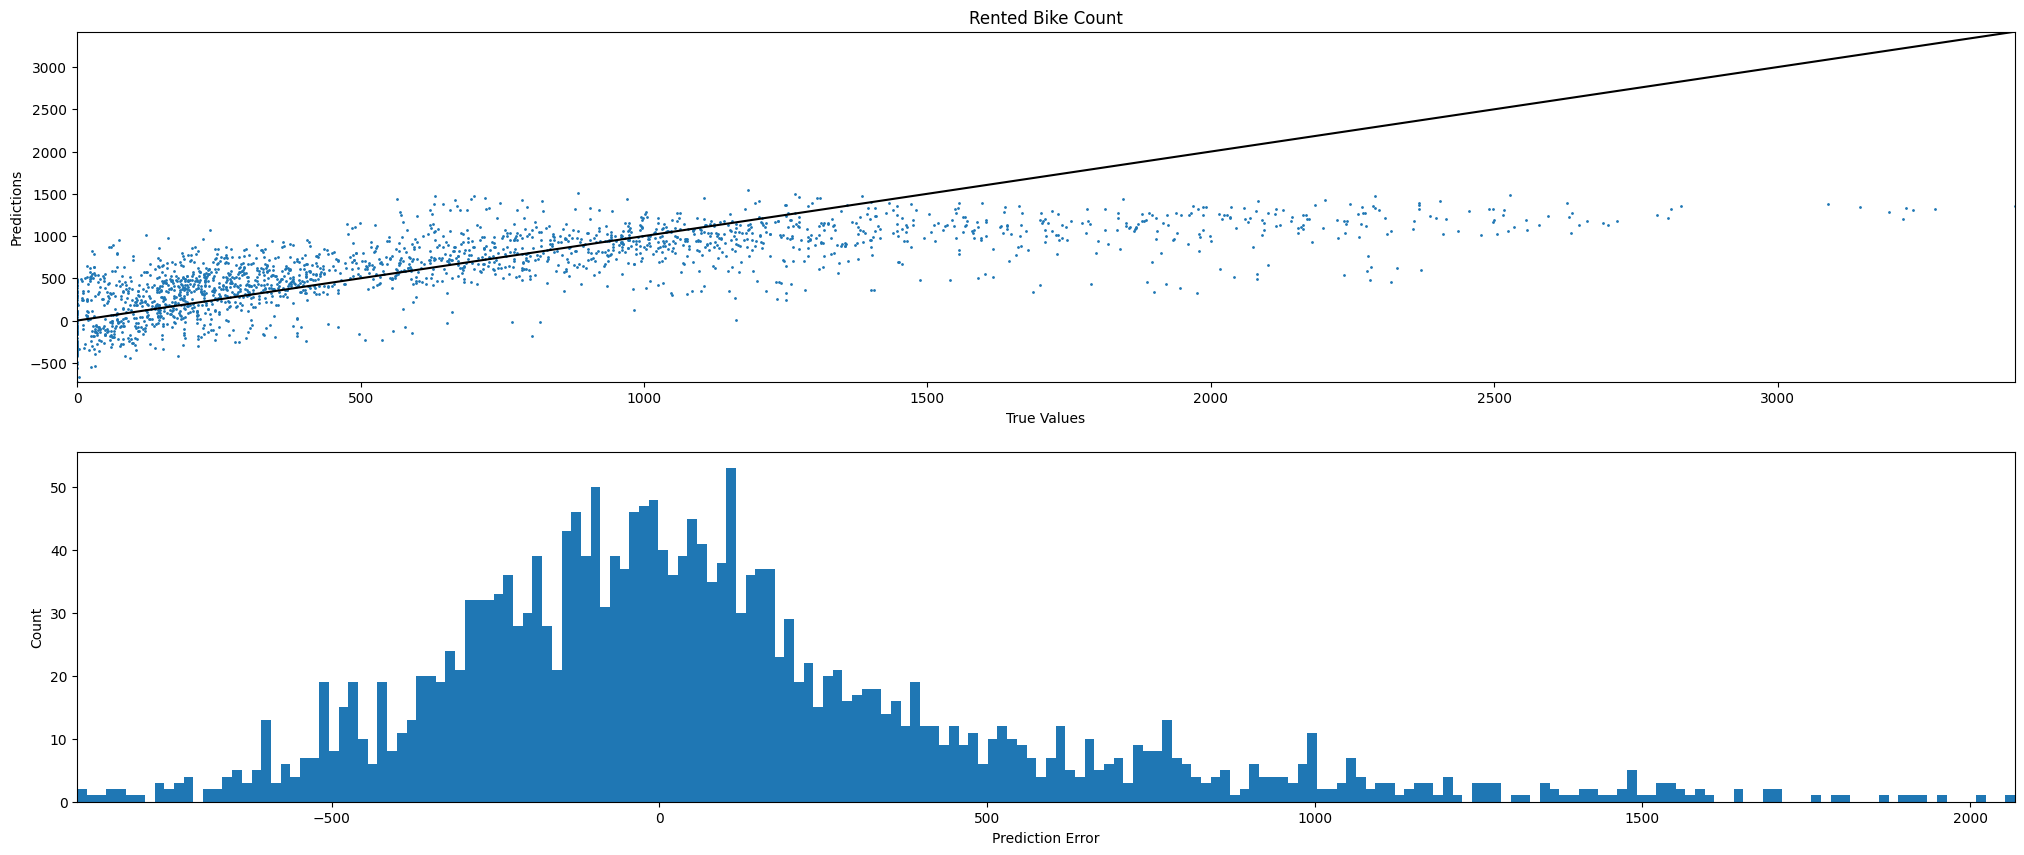

In [40]:
plot_prediction_results(test_y,test_y_pred,target_data,200)

In [44]:
rmse_test_instances = root_mean_squared_error(test_y.transpose(),test_y_pred.transpose(),multioutput='raw_values')

rmse_test_instances_sorted_indices=np.argsort(rmse_test_instances)

# best predictions
print("BEST predictions")
with np.printoptions(precision=1, suppress=True):
  print('RMSE:')
  print(rmse_test_instances[rmse_test_instances_sorted_indices[:row_count]])

  print('True values:')
  print(test_y[rmse_test_instances_sorted_indices[:row_count]])

  print('Predicted values:')
  print(test_y_pred[rmse_test_instances_sorted_indices[:row_count]])

BEST predictions
RMSE:
[0.1 0.1 0.5 0.5 0.6]
True values:
[[ 122]
 [ 972]
 [  63]
 [1088]
 [  60]]
Predicted values:
[[ 121.9]
 [ 971.9]
 [  63.5]
 [1088.5]
 [  60.6]]


In [45]:
# worst predictions
print("WORST predictions")
with np.printoptions(precision=1, suppress=True):
  print('RMSE:')
  print(rmse_test_instances[rmse_test_instances_sorted_indices[-row_count:]])

  print('True values:')
  print(test_y[rmse_test_instances_sorted_indices[-row_count:]])

  print('Predicted values:')
  print(test_y_pred[rmse_test_instances_sorted_indices[-row_count:]])

WORST predictions
RMSE:
[1907.5 1930.  1952.4 2013.8 2068. ]
True values:
[[3196]
 [3238]
 [3277]
 [3221]
 [3418]]
Predicted values:
[[1288.5]
 [1308. ]
 [1324.6]
 [1207.2]
 [1350. ]]


## Deep neural network approach

In [46]:
def build_dnn(input_count, output_count, neuron_count_per_hidden_layer=[128, 128], activation='relu'):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_count,)))

    for n in neuron_count_per_hidden_layer:
        model.add(layers.Dense(n, activation = activation))

    model.add(layers.Dense(output_count))

    return model

In [47]:
dnn = build_dnn(train_x.shape[1], train_y.shape[1])

In [48]:
dnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,073 (74.50 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 0 (0.00 B)

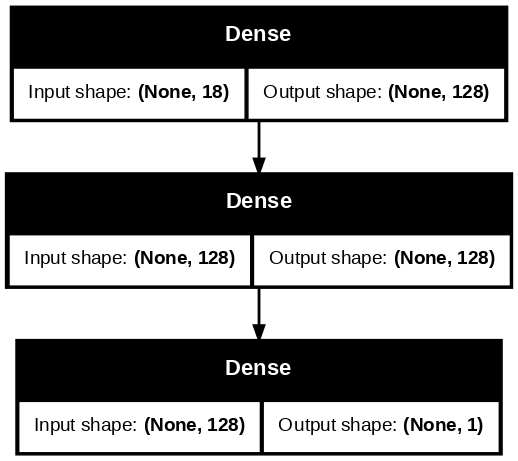

In [49]:
keras.utils.plot_model(dnn,show_shapes=True, show_layer_names=False,dpi=100)

In [50]:
dnn.compile(loss='mse', optimizer='SGD',metrics=[keras.metrics.RootMeanSquaredError(name='rmse')])

In [54]:
epoch_count = 100
batch_size = 512
learning_rate = 0.0001
patience = 5

dnn = build_dnn(train_x.shape[1], train_y.shape[1])

optimizer = keras.optimizers.SGD(learning_rate = learning_rate)

dnn.compile(loss='mse', optimizer = optimizer, metrics = [keras.metrics.RootMeanSquaredError(name='rmse')])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)

history = dnn.fit(train_x, train_y,validation_data=(val_x,val_y), epochs=epoch_count, batch_size=batch_size,shuffle = True)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 832049.4375 - rmse: 912.1674 - val_loss: 930983.9375 - val_rmse: 964.8751
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 888146.6875 - rmse: 942.4153 - val_loss: 858848.5000 - val_rmse: 926.7408
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 543306.1250 - rmse: 737.0930 - val_loss: 1398689.7500 - val_rmse: 1182.6621
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 943348.8125 - rmse: 971.2615 - val_loss: 888741.1875 - val_rmse: 942.7307
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 576413.5000 - rmse: 759.2190 - val_loss: 773887.9375 - val_rmse: 879.7090
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 793912.6250 - rmse: 891.0178 - val_loss: 919457.6250 - val_rmse: 958.8835
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 766748.0000 - rmse: 875.6415 - val_loss: 572883.5000 - val_rmse: 756.8907
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 

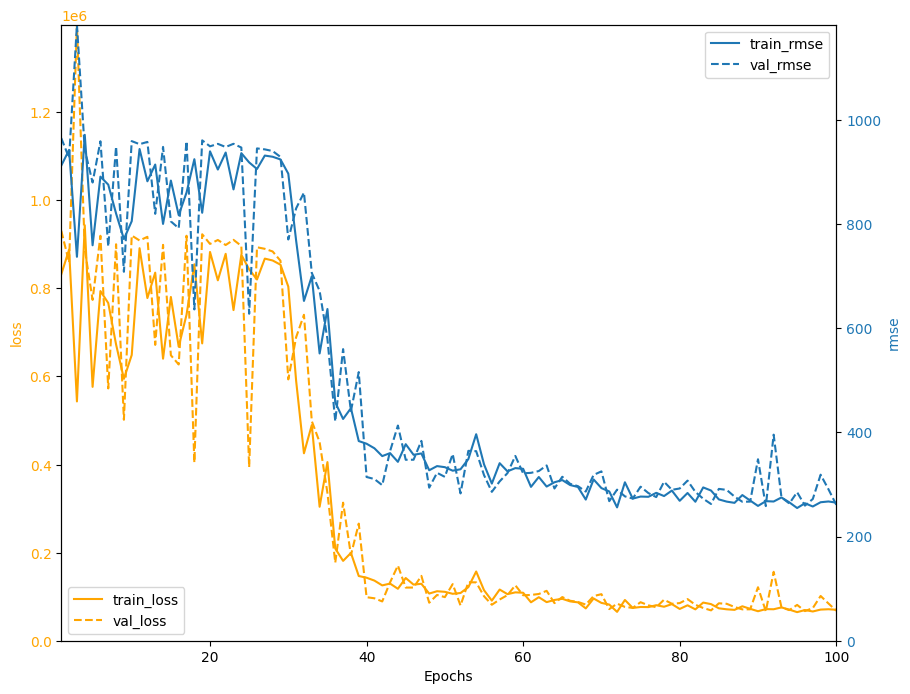

In [55]:
plot_history(history,'rmse')

## Performance evaluation

In [56]:
train_y_pred = dnn.predict(train_x)
val_y_pred = dnn.predict(val_x)

print('Train predictions shape: ',train_y_pred.shape)
print('Validation predictions shape: ',val_y_pred.shape)

154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Train predictions shape:  (4927, 1)
Validation predictions shape:  (1643, 1)
